# Unemployment Analysis with Python

**Oasis Infobyte — Data Science Internship**  
**Task 2 — Unemployment Analysis with Python**  
**Author:** Md. Zayed Hossain

This notebook explores unemployment, employment and labour-participation trends in India during 2020. It includes data cleaning, feature engineering, exploratory analysis, visualizations and saved findings.


## Objective

- Load and clean the Indian unemployment dataset.
- Compare unemployment rates across regions.
- Study monthly trends and the effect of the COVID-19 lockdown period.
- Explore relationships between unemployment, employment and labour participation.
- Save charts and summary CSV files for the project submission.

**Dataset source:** [Unemployment Rate in India](https://github.com/radhikasharma-0203/OASIS-INFOBYTE-INTERNSHIP-OIBSIP/blob/main/Unemployment_Rate_upto_11_2020.csv)


In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.max_columns', None)

RANDOM_STATE = 42
PROJECT_ROOT = Path.cwd()
DATA_DIR = PROJECT_ROOT / 'data'
IMAGES_DIR = PROJECT_ROOT / 'images'
OUTPUTS_DIR = PROJECT_ROOT / 'outputs'
for directory in (DATA_DIR, IMAGES_DIR, OUTPUTS_DIR):
    directory.mkdir(exist_ok=True)

LOCAL_DATA = DATA_DIR / 'Unemployment_Rate_upto_11_2020.csv'
DATA_URL = (
    'https://raw.githubusercontent.com/'
    'radhikasharma-0203/OASIS-INFOBYTE-INTERNSHIP-OIBSIP/'
    'main/Unemployment_Rate_upto_11_2020.csv'
)

print('Project folders are ready.')


Project folders are ready.


## 1. Load the Dataset

In [2]:
if LOCAL_DATA.exists():
    df = pd.read_csv(LOCAL_DATA)
    source_used = f'Local file: {LOCAL_DATA}'
else:
    df = pd.read_csv(DATA_URL)
    df.to_csv(LOCAL_DATA, index=False)
    source_used = DATA_URL

df.columns = df.columns.str.strip()
print('Source:', source_used)
print('Shape:', df.shape)
display(df.head())


Source: https://raw.githubusercontent.com/radhikasharma-0203/OASIS-INFOBYTE-INTERNSHIP-OIBSIP/main/Unemployment_Rate_upto_11_2020.csv
Shape: (267, 9)


,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Region.1,longitude,latitude
0,Andhra Pradesh,31-01-2020,M,5.48,16635535,41.02,South,15.9129,79.74
1,Andhra Pradesh,29-02-2020,M,5.83,16545652,40.90,South,15.9129,79.74
2,Andhra Pradesh,31-03-2020,M,5.79,15881197,39.18,South,15.9129,79.74
3,Andhra Pradesh,30-04-2020,M,20.51,11336911,33.10,South,15.9129,79.74
4,Andhra Pradesh,31-05-2020,M,17.43,12988845,36.46,South,15.9129,79.74


## 2. Data Cleaning and Feature Engineering

In [3]:
# Standardize text fields.
df['Region'] = df['Region'].astype(str).str.strip()
df['Frequency'] = df['Frequency'].astype(str).str.strip()

# Convert dates and numeric fields safely.
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True, errors='coerce')
numeric_columns = [
    'Estimated Unemployment Rate (%)',
    'Estimated Employed',
    'Estimated Labour Participation Rate (%)',
    'longitude',
    'latitude',
]
for column in numeric_columns:
    df[column] = pd.to_numeric(df[column], errors='coerce')

before_rows = len(df)
df = df.drop_duplicates().dropna(
    subset=['Region', 'Date', 'Estimated Unemployment Rate (%)',
            'Estimated Employed', 'Estimated Labour Participation Rate (%)']
).copy()

df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Month_Name'] = df['Date'].dt.strftime('%b')
df['Period'] = df['Date'].dt.to_period('M').astype(str)
df['Lockdown_Period'] = np.where(
    df['Date'] >= pd.Timestamp('2020-03-01'),
    'Lockdown period',
    'Before lockdown'
)

print('Rows before cleaning:', before_rows)
print('Rows after cleaning:', len(df))
print('Duplicate rows remaining:', int(df.duplicated().sum()))
print('Missing values remaining:', int(df.isna().sum().sum()))
display(df.head())


Rows before cleaning: 267
Rows after cleaning: 267
Duplicate rows remaining: 0
Missing values remaining: 0


,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Region.1,longitude,latitude,Year,Month,Month_Name,Period,Lockdown_Period
0,Andhra Pradesh,2020-01-31,M,5.48,16635535,41.02,South,15.9129,79.74,2020,1,Jan,2020-01,Before lockdown
1,Andhra Pradesh,2020-02-29,M,5.83,16545652,40.90,South,15.9129,79.74,2020,2,Feb,2020-02,Before lockdown
2,Andhra Pradesh,2020-03-31,M,5.79,15881197,39.18,South,15.9129,79.74,2020,3,Mar,2020-03,Lockdown period
3,Andhra Pradesh,2020-04-30,M,20.51,11336911,33.10,South,15.9129,79.74,2020,4,Apr,2020-04,Lockdown period
4,Andhra Pradesh,2020-05-31,M,17.43,12988845,36.46,South,15.9129,79.74,2020,5,May,2020-05,Lockdown period


## 3. Initial Inspection

In [4]:
display(df[['Estimated Unemployment Rate (%)',
             'Estimated Employed',
             'Estimated Labour Participation Rate (%)']].describe().round(2))

print('Regions:', df['Region'].nunique())
print('Date range:', df['Date'].min().date(), 'to', df['Date'].max().date())
display(df.isna().sum().sort_values(ascending=False).to_frame('missing_values'))


,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
count,267.00,267.00,267.00
mean,12.24,13962105.72,41.68
std,10.80,13366318.36,7.85
min,0.50,117542.00,16.77
25%,4.84,2838930.50,37.26
50%,9.65,9732417.00,40.39
75%,16.76,21878686.00,44.06
max,75.85,59433759.00,69.69


Regions: 27
Date range: 2020-01-31 to 2020-10-31


,missing_values
Region,0
Date,0
Frequency,0
Estimated Unemployment Rate (%),0
Estimated Employed,0
Estimated Labour Participation Rate (%),0
Region.1,0
longitude,0
latitude,0
Year,0


## 4. Exploratory Data Analysis

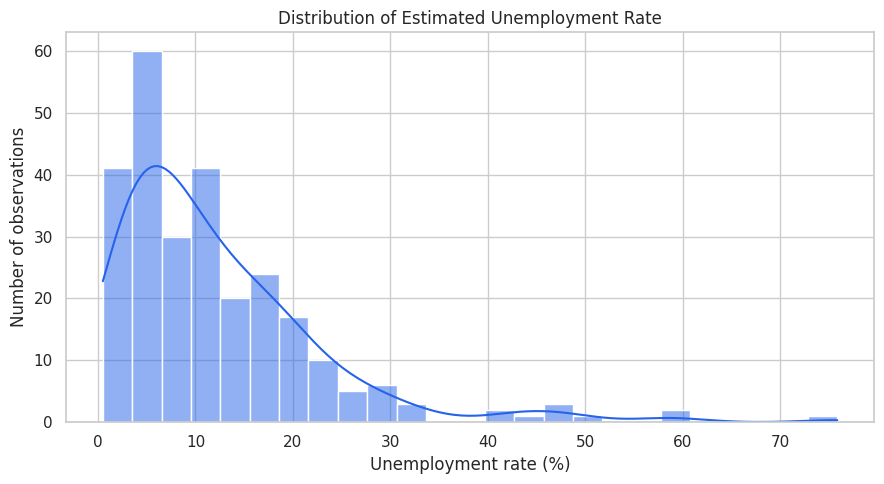

In [5]:
plt.figure(figsize=(9, 5))
sns.histplot(
    data=df,
    x='Estimated Unemployment Rate (%)',
    bins=25,
    kde=True,
    color='#2563eb'
)
plt.title('Distribution of Estimated Unemployment Rate')
plt.xlabel('Unemployment rate (%)')
plt.ylabel('Number of observations')
plt.tight_layout()
plt.savefig(IMAGES_DIR / 'unemployment_rate_distribution.png', dpi=180, bbox_inches='tight')
plt.show()


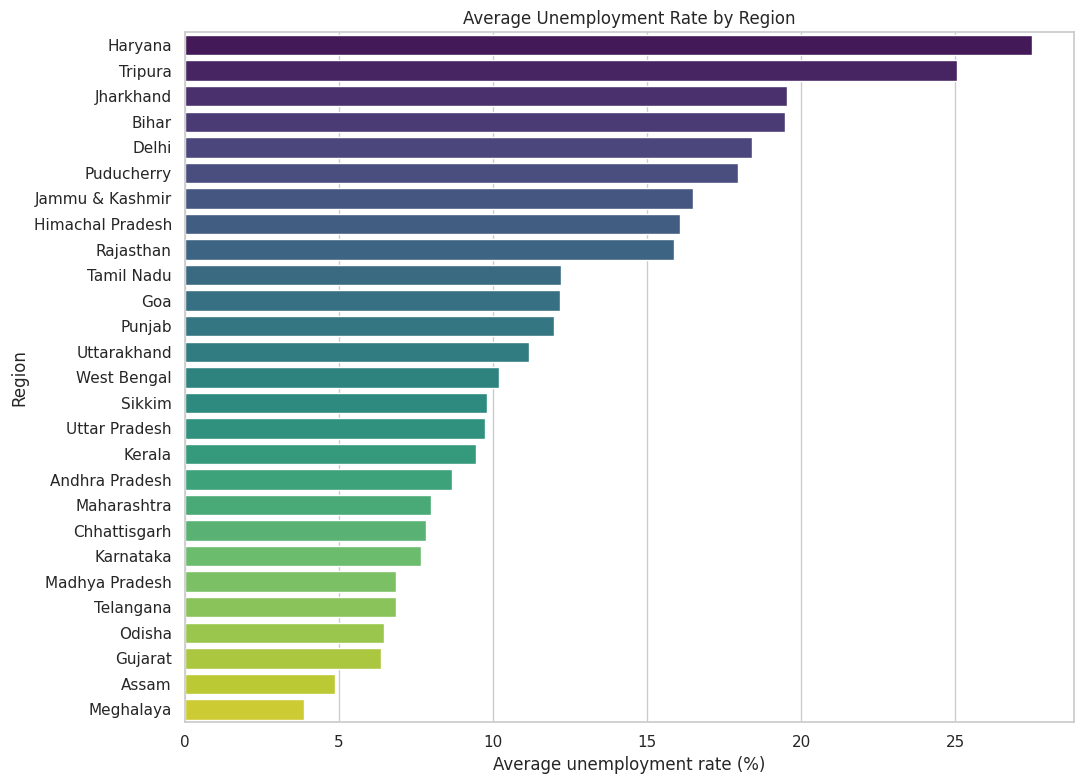

,Region,average_unemployment_rate,average_employed,average_labour_participation,observations
7,Haryana,27.48,6844059.00,42.10,10
23,Tripura,25.06,1397291.60,57.85,10
10,Jharkhand,19.54,8770642.40,40.36,10
2,Bihar,19.47,23606828.00,37.17,10
4,Delhi,18.41,4632821.90,35.86,10
17,Puducherry,17.94,365262.90,35.92,10
9,Jammu & Kashmir,16.48,3310031.67,37.89,9
8,Himachal Pradesh,16.07,2033884.90,40.25,10
19,Rajasthan,15.87,19731752.20,40.59,10
21,Tamil Nadu,12.19,21987898.10,37.38,10


In [6]:
regional_summary = (
    df.groupby('Region', as_index=False)
      .agg(
          average_unemployment_rate=('Estimated Unemployment Rate (%)', 'mean'),
          average_employed=('Estimated Employed', 'mean'),
          average_labour_participation=('Estimated Labour Participation Rate (%)', 'mean'),
          observations=('Region', 'size')
      )
      .sort_values('average_unemployment_rate', ascending=False)
)

plt.figure(figsize=(11, 8))
sns.barplot(
    data=regional_summary,
    y='Region',
    x='average_unemployment_rate',
    hue='Region',
    palette='viridis',
    legend=False
)
plt.title('Average Unemployment Rate by Region')
plt.xlabel('Average unemployment rate (%)')
plt.ylabel('Region')
plt.tight_layout()
plt.savefig(IMAGES_DIR / 'average_unemployment_by_region.png', dpi=180, bbox_inches='tight')
plt.show()

display(regional_summary.head(10).round(2))


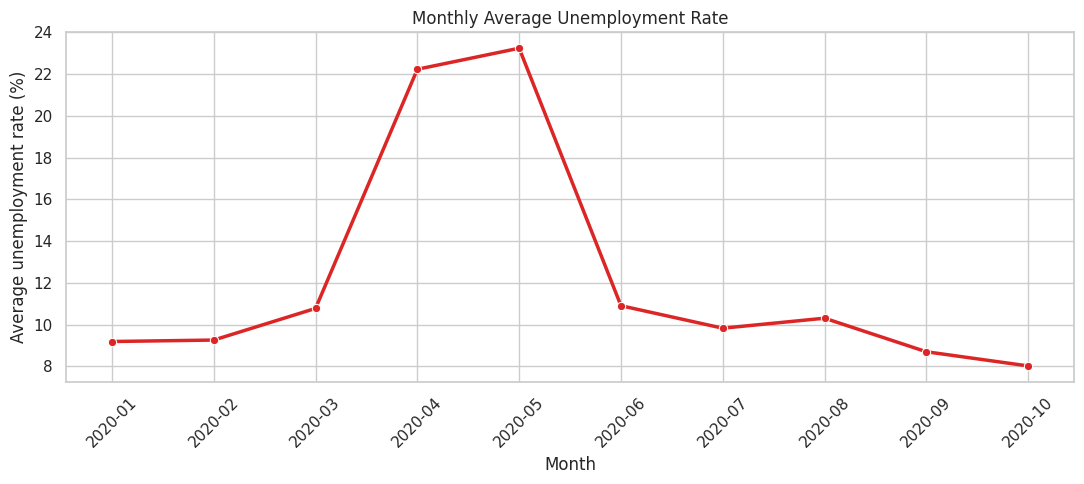

,Period,average_unemployment_rate,average_employed,average_labour_participation
0,2020-01,9.20,15637199.77,44.63
1,2020-02,9.27,15488266.04,44.18
2,2020-03,10.78,14538659.89,43.75
3,2020-04,22.24,10570199.00,35.30
4,2020-05,23.24,11507394.85,39.65
5,2020-06,10.91,13857393.81,41.20
6,2020-07,9.83,14418021.48,42.27
7,2020-08,10.31,14429042.04,42.39
8,2020-09,8.71,14587838.63,41.97
9,2020-10,8.03,14579980.52,41.44


In [7]:
monthly_summary = (
    df.groupby('Period', as_index=False)
      .agg(
          average_unemployment_rate=('Estimated Unemployment Rate (%)', 'mean'),
          average_employed=('Estimated Employed', 'mean'),
          average_labour_participation=('Estimated Labour Participation Rate (%)', 'mean')
      )
      .sort_values('Period')
)

plt.figure(figsize=(11, 5))
sns.lineplot(
    data=monthly_summary,
    x='Period',
    y='average_unemployment_rate',
    marker='o',
    linewidth=2.5,
    color='#dc2626'
)
plt.title('Monthly Average Unemployment Rate')
plt.xlabel('Month')
plt.ylabel('Average unemployment rate (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(IMAGES_DIR / 'monthly_unemployment_trend.png', dpi=180, bbox_inches='tight')
plt.show()

display(monthly_summary.round(2))


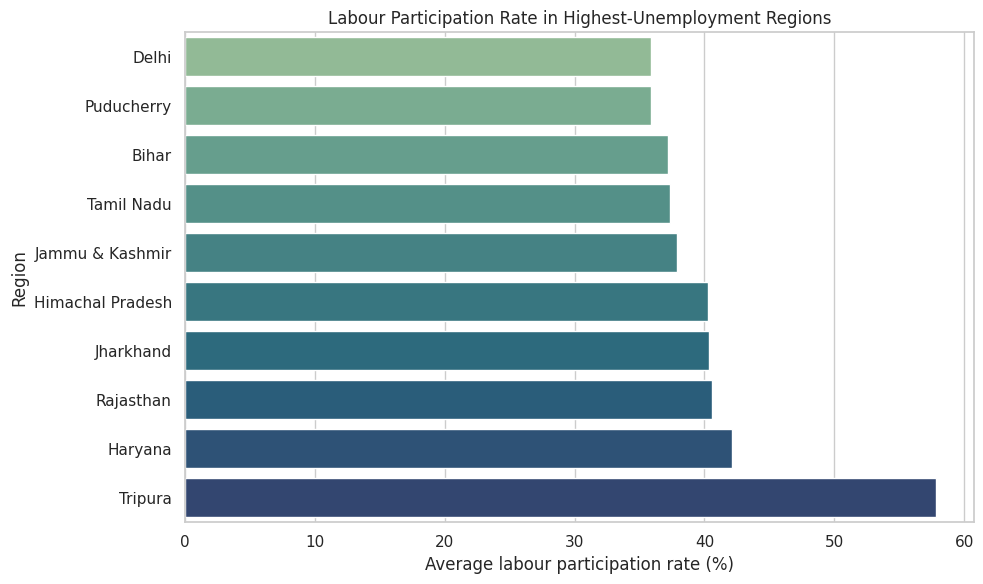

In [8]:
top_regions = regional_summary.head(10).sort_values('average_labour_participation')

plt.figure(figsize=(10, 6))
sns.barplot(
    data=top_regions,
    y='Region',
    x='average_labour_participation',
    hue='Region',
    palette='crest',
    legend=False
)
plt.title('Labour Participation Rate in Highest-Unemployment Regions')
plt.xlabel('Average labour participation rate (%)')
plt.ylabel('Region')
plt.tight_layout()
plt.savefig(IMAGES_DIR / 'labour_participation_top_regions.png', dpi=180, bbox_inches='tight')
plt.show()


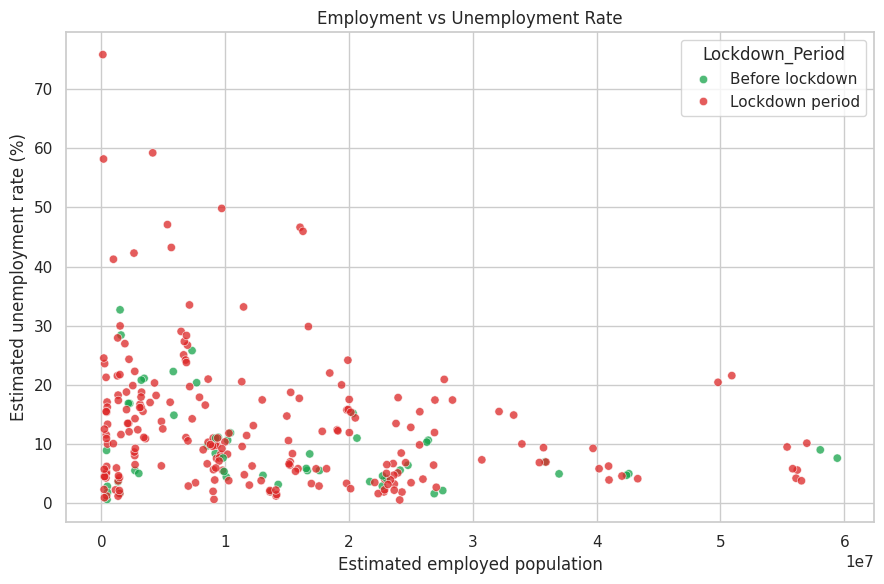

In [9]:
plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=df,
    x='Estimated Employed',
    y='Estimated Unemployment Rate (%)',
    hue='Lockdown_Period',
    palette={'Before lockdown': '#16a34a', 'Lockdown period': '#dc2626'},
    alpha=0.75
)
plt.title('Employment vs Unemployment Rate')
plt.xlabel('Estimated employed population')
plt.ylabel('Estimated unemployment rate (%)')
plt.tight_layout()
plt.savefig(IMAGES_DIR / 'employment_vs_unemployment_scatter.png', dpi=180, bbox_inches='tight')
plt.show()


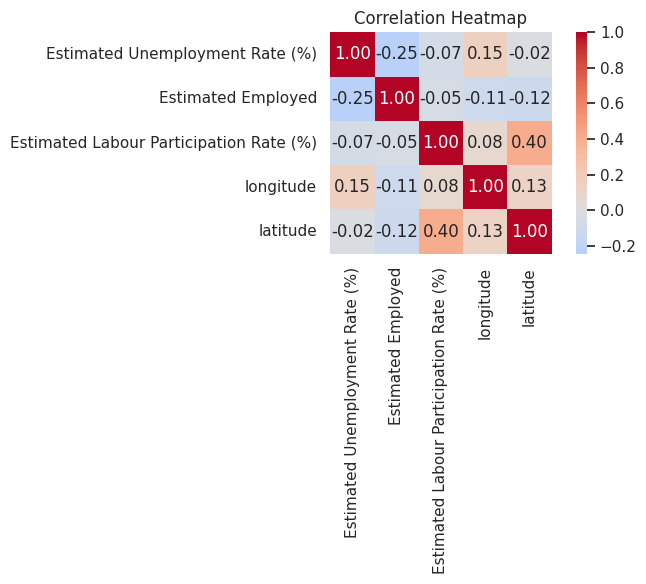

In [10]:
correlation_columns = [
    'Estimated Unemployment Rate (%)',
    'Estimated Employed',
    'Estimated Labour Participation Rate (%)',
    'longitude',
    'latitude'
]

plt.figure(figsize=(8, 6))
sns.heatmap(
    df[correlation_columns].corr(numeric_only=True),
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    square=True
)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.savefig(IMAGES_DIR / 'unemployment_correlation_heatmap.png', dpi=180, bbox_inches='tight')
plt.show()


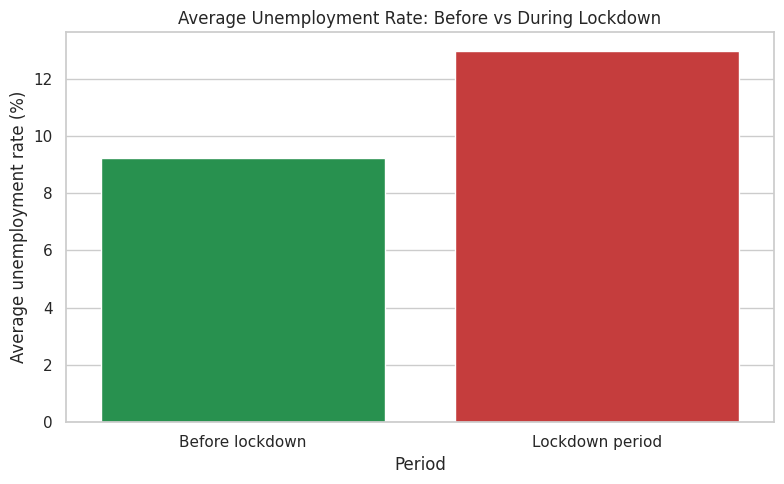

,Lockdown_Period,average_unemployment_rate,average_employed,average_labour_participation,observations
0,Before lockdown,9.23,15562732.90,44.40,52
1,Lockdown period,12.96,13574977.29,41.02,215


In [11]:
lockdown_summary = (
    df.groupby('Lockdown_Period', as_index=False)
      .agg(
          average_unemployment_rate=('Estimated Unemployment Rate (%)', 'mean'),
          average_employed=('Estimated Employed', 'mean'),
          average_labour_participation=('Estimated Labour Participation Rate (%)', 'mean'),
          observations=('Lockdown_Period', 'size')
      )
)

plt.figure(figsize=(8, 5))
sns.barplot(
    data=lockdown_summary,
    x='Lockdown_Period',
    y='average_unemployment_rate',
    hue='Lockdown_Period',
    palette={'Before lockdown': '#16a34a', 'Lockdown period': '#dc2626'},
    legend=False
)
plt.title('Average Unemployment Rate: Before vs During Lockdown')
plt.xlabel('Period')
plt.ylabel('Average unemployment rate (%)')
plt.tight_layout()
plt.savefig(IMAGES_DIR / 'lockdown_period_comparison.png', dpi=180, bbox_inches='tight')
plt.show()

display(lockdown_summary.round(2))


## 5. Save Project Outputs

In [12]:
regional_summary.to_csv(OUTPUTS_DIR / 'regional_unemployment_summary.csv', index=False)
monthly_summary.to_csv(OUTPUTS_DIR / 'monthly_unemployment_summary.csv', index=False)
lockdown_summary.to_csv(OUTPUTS_DIR / 'lockdown_comparison.csv', index=False)
df.to_csv(OUTPUTS_DIR / 'cleaned_unemployment_data.csv', index=False)

highest_region = regional_summary.iloc[0]
lowest_region = regional_summary.iloc[-1]
before_rate = lockdown_summary.loc[
    lockdown_summary['Lockdown_Period'] == 'Before lockdown',
    'average_unemployment_rate'
]
lockdown_rate = lockdown_summary.loc[
    lockdown_summary['Lockdown_Period'] == 'Lockdown period',
    'average_unemployment_rate'
]

before_value = float(before_rate.iloc[0]) if len(before_rate) else np.nan
lockdown_value = float(lockdown_rate.iloc[0]) if len(lockdown_rate) else np.nan
change_pct = ((lockdown_value - before_value) / before_value * 100) if before_value else np.nan

findings = f'''Unemployment Analysis Findings
================================
Rows analysed: {len(df)}
Regions analysed: {df['Region'].nunique()}
Date range: {df['Date'].min().date()} to {df['Date'].max().date()}
Highest average unemployment region: {highest_region['Region']} ({highest_region['average_unemployment_rate']:.2f}%)
Lowest average unemployment region: {lowest_region['Region']} ({lowest_region['average_unemployment_rate']:.2f}%)
Average unemployment before lockdown: {before_value:.2f}%
Average unemployment during lockdown: {lockdown_value:.2f}%
Percentage change from before lockdown to lockdown: {change_pct:.2f}%
'''
(OUTPUTS_DIR / 'findings.txt').write_text(findings, encoding='utf-8')

print(findings)
print('Saved chart files:', len(list(IMAGES_DIR.glob('*.png'))))
print('Saved output files:', len(list(OUTPUTS_DIR.iterdir())))


Unemployment Analysis Findings
Rows analysed: 267
Regions analysed: 27
Date range: 2020-01-31 to 2020-10-31
Highest average unemployment region: Haryana (27.48%)
Lowest average unemployment region: Meghalaya (3.87%)
Average unemployment before lockdown: 9.23%
Average unemployment during lockdown: 12.96%
Percentage change from before lockdown to lockdown: 40.43%

Saved chart files: 7
Saved output files: 5


## Conclusion

The analysis compares regional unemployment, monthly trends, labour participation and the lockdown period. The saved charts and CSV files in `images/` and `outputs/` can be uploaded with the executed notebook to GitHub.

Run the notebook with **Runtime → Run all** in Google Colab. When every cell finishes without a red error, download the executed `.ipynb` file.
